<a href="https://colab.research.google.com/github/VENOMxLEGIT/E-Commerce-sales-python-project/blob/main/E_Commerce_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

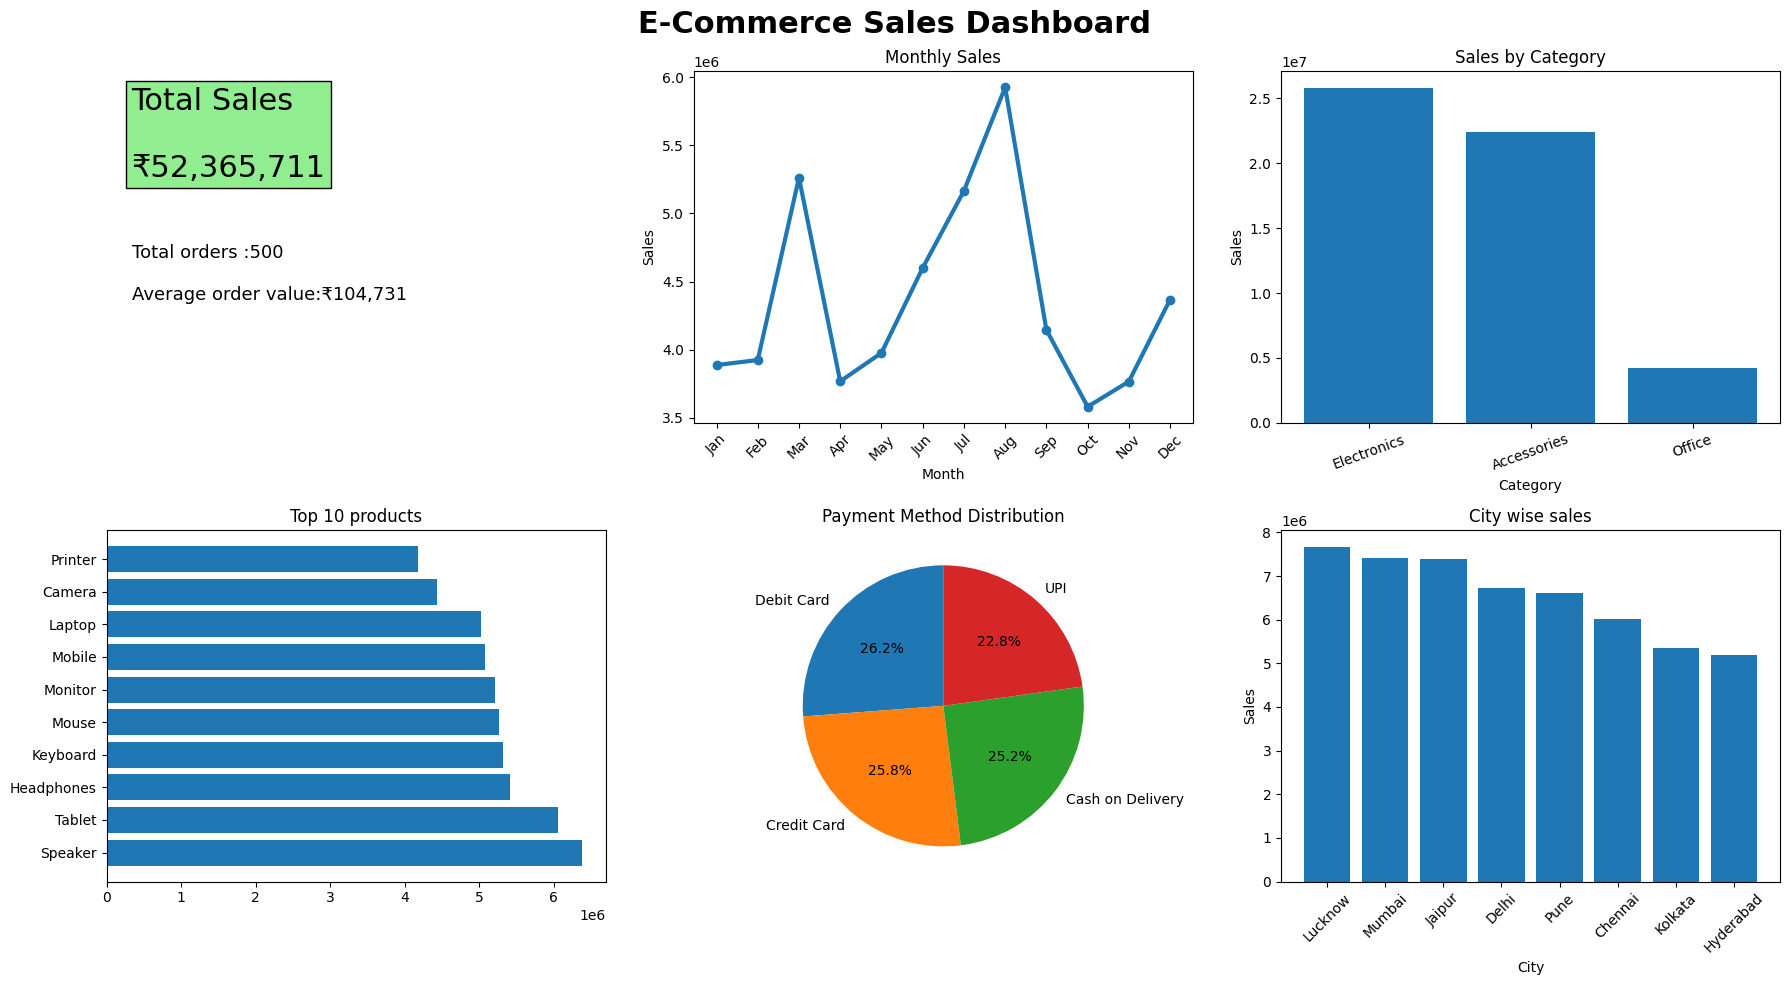

E-COMMERCE SALES REPORT
Total Orders          : 500
Total Sales           : ₹52,365,711
Average Order Value   : ₹104,731.42

Highest Selling Product
Speaker

Best Performing Category
Electronics

Best Performing City
Lucknow

Most Used Payment Method
Debit Card


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ecommerce_sales_data.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["month"] = df["Order_Date"].dt.strftime("%b")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

total_orders = len(df)
total_sales = df["Sales"].sum()
average_orders = df["Sales"].mean()


monthly_sales = (df.groupby("month") ["Sales"]
                 .sum()
                 .sort_values(ascending=False)
                 .reindex(month_order)
)


category_sales = (df.groupby("Category") ["Sales"]
                  .sum()
                  .sort_values(ascending=False))

top_products = (df.groupby("Product") ["Sales"]
                .sum()
                .sort_values(ascending=False)
                .head(10))

city_sales = (df.groupby("City") ["Sales"]
              .sum()
              .sort_values(ascending=False))

payment_methods = df["Payment"].value_counts()

# dashboard
plt.figure(figsize=(18,10))
plt.suptitle("E-Commerce Sales Dashboard",fontsize =22,fontweight = "bold")

# total sales
plt.subplot(2,3,1)
plt.axis("off")

plt.text(
    0.05,
    0.70,
    f"Total Sales\n\n₹{total_sales:,.0f}",
    fontsize=22,
    bbox=dict(facecolor="lightgreen", edgecolor="black"))

plt.text(
    0.05,
    0.35,
    f"Total orders :{total_orders}\n\nAverage order value:₹{average_orders:,.0f}",
    fontsize=13)

# monthly sales
plt.subplot(2,3,2)
plt.plot(
         monthly_sales.index,
         monthly_sales.values,
         marker = "o",
         linewidth=3
         )
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

# category sales
plt.subplot(2,3,3)

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=20)



# Top Products
plt.subplot(2,3,4)
plt.barh(
    top_products.index,
    top_products.values
)
plt.title("Top 10 products")
# plt.xlable("Sales")


# payment distribution
plt.subplot(2,3,5)
plt.pie(
    payment_methods.values,
    labels=payment_methods.index,
    autopct="%1.1f%%",
    startangle =90
)
plt.title("Payment Method Distribution")


# city sales
plt.subplot(2,3,6)
plt.bar(
    city_sales.index,
    city_sales.values
)
plt.title("City wise sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# report
print("="*50)
print("E-COMMERCE SALES REPORT")
print("="*50)

print(f"Total Orders          : {total_orders}")
print(f"Total Sales           : ₹{total_sales:,.0f}")
print(f"Average Order Value   : ₹{average_orders:,.2f}")

print("\nHighest Selling Product")
print(df.groupby("Product")["Sales"].sum().idxmax())

print("\nBest Performing Category")
print(df.groupby("Category")["Sales"].sum().idxmax())

print("\nBest Performing City")
print(df.groupby("City")["Sales"].sum().idxmax())

print("\nMost Used Payment Method")
print(payment_methods.idxmax())






